# Logical Pair Simulation Plots

This notebook loads runner logs and plots end-to-end logical-pair performance across different network and hardware settings.


In [59]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/two_qubit_gate_sweep")

## Load and Parse Logs

This cell scans the runner log directory, extracts experiment metadata from each filename, and parses the `run_id`, `time to serve`, and `fidelity` values from each log line.

In [60]:
filename_re = re.compile(r"line_(?P<nodes>\d+)_2G,code=(?P<code>\[\[.*?\]\]),dist=(?P<dist>[0-9.]+),gate=(?P<gate>[0-9.]+),twoq=(?P<twoq>[0-9.]+),dataT2=(?P<data_t2>[0-9.]+),commT2=(?P<comm_t2>[0-9.]+),ft=(?P<ft>[a-zA-Z0-9_]+),pauli=(?P<pauli>[0-9._]+)")
line_re = re.compile(r"run_id=(?P<run_id>\d+), time to serve=(?P<time>[0-9.]+), fidelity=(?P<fidelity>[0-9.]+)")

rows = []
for path in sorted(log_dir.iterdir()):
    if not path.is_file() or path.stat().st_size == 0:
        continue
    filename_match = filename_re.search(path.name)
    if filename_match is None:
        continue
    meta = filename_match.groupdict()
    with path.open("r", encoding="utf-8") as file:
        for line in file:
            line_match = line_re.search(line)
            if line_match is None:
                continue
            rows.append({
                "file": path.name,
                "nodes": int(meta["nodes"]),
                "dist_km": float(meta["dist"]),
                "gate_fidelity": float(meta["gate"]),
                "two_qubit_gate_fidelity": float(meta["twoq"]),
                "idle_data_coherence_time_sec": float(meta["data_t2"]),
                "idle_comm_coherence_time_sec": float(meta["comm_t2"]),
                "ft_prep_mode": meta["ft"],
                "idle_pauli_weights": meta["pauli"],
                "css_code": meta["code"],
                "run_id": int(line_match["run_id"]),
                "time_to_serve_ms": float(line_match["time"]),
                "fidelity": float(line_match["fidelity"]),
            })

df = pd.DataFrame(rows).sort_values(["nodes", "dist_km", "two_qubit_gate_fidelity", "run_id"]).reset_index(drop=True)
df.head()


,file,nodes,dist_km,gate_fidelity,two_qubit_gate_fidelity,idle_data_coherence_time_sec,idle_comm_coherence_time_sec,ft_prep_mode,idle_pauli_weights,css_code,run_id,time_to_serve_ms,fidelity
0,"line_5_2G,code=[[7,1,3]],dist=10.0,gate=1.0,tw...",5,10.0,1.0,0.995,1.000000e+12,1.000000e+12,minimal,0.05_0.05_0.9,"[[7,1,3]]",1,5.120313,1.0
1,"line_5_2G,code=[[7,1,3]],dist=10.0,gate=1.0,tw...",5,10.0,1.0,0.995,1.000000e+12,1.000000e+12,minimal,0.05_0.05_0.9,"[[7,1,3]]",2,4.690276,1.0
2,"line_5_2G,code=[[7,1,3]],dist=10.0,gate=1.0,tw...",5,10.0,1.0,0.995,1.000000e+12,1.000000e+12,minimal,0.05_0.05_0.9,"[[7,1,3]]",3,6.570425,1.0
3,"line_5_2G,code=[[7,1,3]],dist=10.0,gate=1.0,tw...",5,10.0,1.0,0.995,1.000000e+12,1.000000e+12,minimal,0.05_0.05_0.9,"[[7,1,3]]",4,4.840288,1.0
4,"line_5_2G,code=[[7,1,3]],dist=10.0,gate=1.0,tw...",5,10.0,1.0,0.995,1.000000e+12,1.000000e+12,minimal,0.05_0.05_0.9,"[[7,1,3]]",5,5.390375,1.0


## Build Summary Table

This cell groups the raw run data by two-qubit gate fidelity, then computes average end-to-end fidelity and the number of completed runs for each setting.


In [61]:
summary = df.groupby("two_qubit_gate_fidelity", as_index=False).agg(
    mean_fidelity=("fidelity", "mean"),
    completed_runs=("run_id", "count"),
)
summary.sort_values("two_qubit_gate_fidelity")


,two_qubit_gate_fidelity,mean_fidelity,completed_runs
0,0.9950,0.87,100
1,0.9980,0.96,100
2,0.9990,0.95,100
3,0.9995,0.99,100
4,0.9999,0.99,100
5,1.0000,1.00,100


## Mean End-to-End Fidelity vs Two-Qubit Gate Fidelity

This plot shows how the average end-to-end fidelity changes as the two-qubit gate fidelity varies.


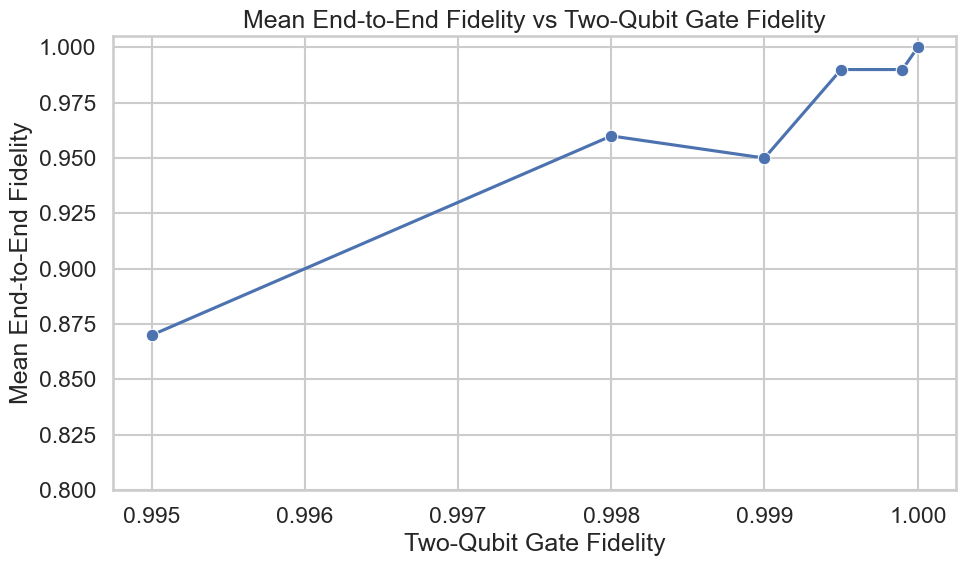

In [62]:

sns.lineplot(data=summary, x="two_qubit_gate_fidelity", y="mean_fidelity", marker="o")
plt.title("Mean End-to-End Fidelity vs Two-Qubit Gate Fidelity")
plt.xlabel("Two-Qubit Gate Fidelity")
plt.ylabel("Mean End-to-End Fidelity")
plt.ylim(0.8, 1.005)
plt.tight_layout()
plt.show()

## Summary Table

This table lists the average end-to-end fidelity and the number of completed runs for each two-qubit gate fidelity setting.


In [63]:
summary


,two_qubit_gate_fidelity,mean_fidelity,completed_runs
0,0.9950,0.87,100
1,0.9980,0.96,100
2,0.9990,0.95,100
3,0.9995,0.99,100
4,0.9999,0.99,100
5,1.0000,1.00,100


## Mean End-to-End Fidelity vs Two-Qubit Gate Fidelity

This plot shows how the average end-to-end fidelity changes as the two-qubit gate fidelity varies. The experiment uses a [[7,1,3]] Steane code on a linear network topology with 2 GHz clock rate. Other fixed parameters: single-qubit gate fidelity = 1.0, data qubit T2 = 10¹² s, communication qubit T2 = 10¹² s, fault-tolerant preparation mode = minimal, and idle Pauli weights = (0.05, 0.05, 0.9).

## Classical Correction Toggle Sweep

This section compares end-to-end fidelity with and without the final classical correction applied.


In [64]:
correction_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/apply_classical_correction_sweep")
correction_filename_re = re.compile(r"line_(?P<nodes>\d+)_2G,code=(?P<code>\[\[.*?\]\]),dist=(?P<dist>[0-9.]+),gate=(?P<gate>[0-9.]+),twoq=(?P<twoq>[0-9.]+),dataT2=(?P<data_t2>[0-9.]+),commT2=(?P<comm_t2>[0-9.]+),ft=(?P<ft>[a-zA-Z0-9_]+),pauli=(?P<pauli>[0-9._]+),ccorr=(?P<ccorr>on|off)")

correction_rows = []
for path in sorted(correction_log_dir.iterdir()):
    if not path.is_file() or path.stat().st_size == 0:
        continue
    filename_match = correction_filename_re.search(path.name)
    if filename_match is None:
        continue
    meta = filename_match.groupdict()
    with path.open("r", encoding="utf-8") as file:
        for line in file:
            line_match = line_re.search(line)
            if line_match is None:
                continue
            correction_rows.append({
                "two_qubit_gate_fidelity": float(meta["twoq"]),
                "apply_classical_correction": meta["ccorr"],
                "run_id": int(line_match["run_id"]),
                "fidelity": float(line_match["fidelity"]),
            })

correction_df = pd.DataFrame(correction_rows)
correction_df.head()


,two_qubit_gate_fidelity,apply_classical_correction,run_id,fidelity
0,0.995,off,1,0.0
1,0.995,off,2,1.0
2,0.995,off,3,0.0
3,0.995,off,4,1.0
4,0.995,off,5,1.0


In [65]:
correction_summary = correction_df.groupby(["two_qubit_gate_fidelity", "apply_classical_correction"], as_index=False).agg(
    mean_fidelity=("fidelity", "mean"),
    completed_runs=("run_id", "count"),
)
correction_summary["apply_classical_correction"] = correction_summary["apply_classical_correction"].map({"off": "No", "on": "Yes"})
correction_summary


,two_qubit_gate_fidelity,apply_classical_correction,mean_fidelity,completed_runs
0,0.9950,No,0.400,100
1,0.9950,Yes,0.670,100
2,0.9980,No,0.470,100
3,0.9980,Yes,0.720,100
4,0.9990,No,0.460,100
5,0.9990,Yes,0.800,100
6,0.9995,No,0.620,100
7,0.9995,Yes,0.800,100
8,0.9999,No,0.540,100
9,0.9999,Yes,0.850,100


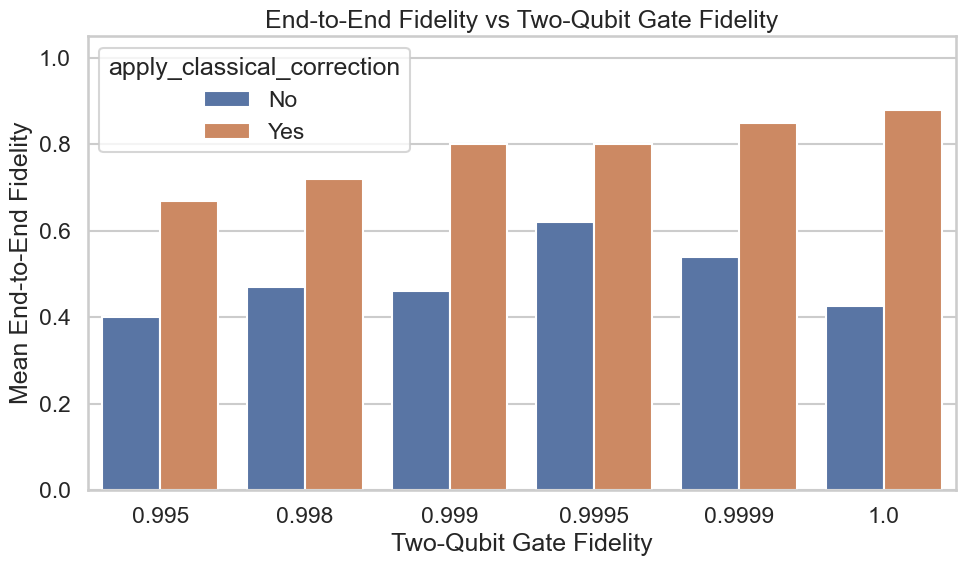

In [66]:
sns.barplot(data=correction_summary, x="two_qubit_gate_fidelity", y="mean_fidelity", hue="apply_classical_correction")
plt.title("End-to-End Fidelity vs Two-Qubit Gate Fidelity")
plt.xlabel("Two-Qubit Gate Fidelity")
plt.ylabel("Mean End-to-End Fidelity")
plt.ylim(0.0, 1.05)
plt.tight_layout()
plt.show()


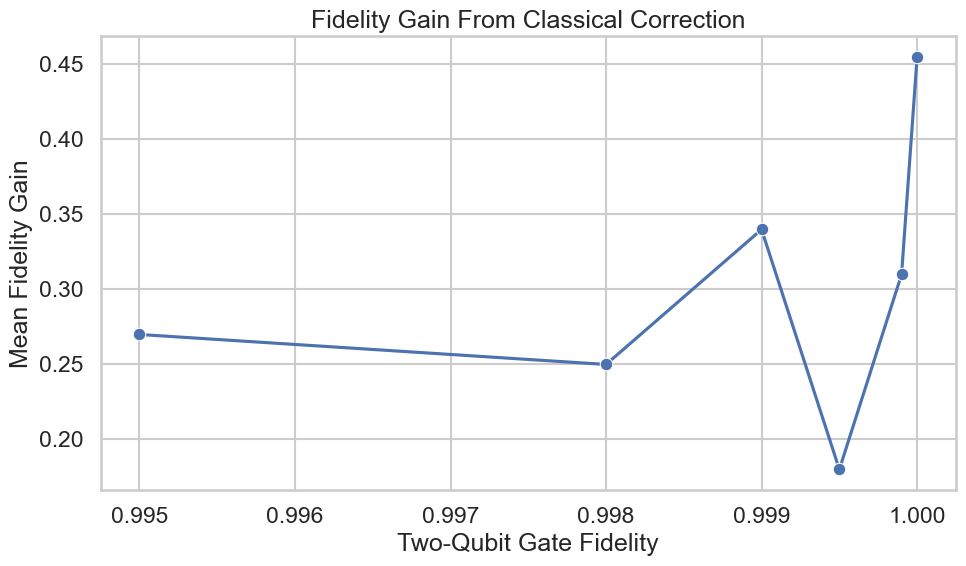

In [67]:
correction_gain_df = correction_summary.pivot(index="two_qubit_gate_fidelity", columns="apply_classical_correction", values="mean_fidelity").reset_index()
correction_gain_df["fidelity_gain_from_correction"] = correction_gain_df["Yes"] - correction_gain_df["No"]
sns.lineplot(data=correction_gain_df, x="two_qubit_gate_fidelity", y="fidelity_gain_from_correction", marker="o")
plt.title("Fidelity Gain From Classical Correction")
plt.xlabel("Two-Qubit Gate Fidelity")
plt.ylabel("Mean Fidelity Gain")
plt.tight_layout()
plt.show()
